In [36]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN


current_dir = Path.cwd()
project_root = current_dir.parents[2]
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
data = pd.read_csv(path_data,index_col=0)

def HY_classification(nhy):
    if nhy == 0:
        return 0  # Healthy
    elif nhy  == 1:
        return 1  # Early Stage
    elif nhy == 2:
        return 2  # Mid Stage
    else:
        return 3  # Advanced Stage

data["STAGE"] = data["NHY"].apply(HY_classification)

V08_cols = ['ENRLLRRK2', 'ENRLGBA', 'COHORT_DEFINITION', 'SEX', 'RAWHITE', 'EDUCYRS', 'AGE_AT_VISIT', "NHY", "STAGE"]
data_V08 = data[V08_cols+['EVENT_ID']].copy()
data_V08 = data_V08.loc[data_V08["EVENT_ID"] == 'V08',:]  # last visit
data_V08.drop(columns=["EVENT_ID",'COHORT_DEFINITION',], inplace=True) 

other_cols = [col for col in data.columns if col not in V08_cols]
data_removed = data[V08_cols].copy()
data_stats = data[other_cols].copy()
data_stats = data_stats.loc[data_stats["EVENT_ID"].isin(['BL','V04','V06']),:]  # last visit
data_stats.drop(columns=["EVENT_ID"], inplace=True)

df_grouped = data_stats.groupby(level="PATNO")

df_mean = df_grouped.mean().add_suffix("_mean")
df_min  = df_grouped.min().add_suffix("_min")
df_max  = df_grouped.max().add_suffix("_max")
df_var  = df_grouped.var().add_suffix("_var")
df_std  = df_grouped.std().add_suffix("_std")

data_stats = pd.concat([df_mean, df_min, df_max, df_var, df_std], axis=1)


In [37]:
print("data_V08:", data_V08.shape)
data_V08.head()

data_V08: (909, 8)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,NHY,STAGE
PATNO,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,2.0,2
3018,0,0,0.0,1.0,16.0,63.6,2.0,2
3020,0,0,0.0,1.0,15.0,77.0,3.0,3
3028,0,0,1.0,1.0,22.0,78.8,2.0,2
3051,0,0,1.0,1.0,18.0,74.7,2.0,2


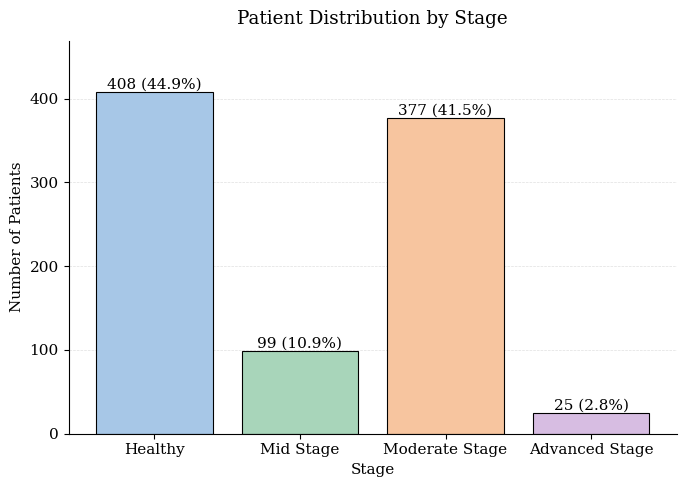

In [39]:
import matplotlib.pyplot as plt

# Conteo asegurando el orden 0-1-2-3
counts = data_V08['STAGE'].value_counts().reindex([0,1,2,3], fill_value=0)

# Etiquetas de cada stage
stage_labels = {
    0: "Healthy",
    1: 'Mid Stage',
    2: "Moderate Stage",
    3: "Advanced Stage"
}

counts_df = counts.reset_index()
counts_df.columns = ['Stage', 'Count']
counts_df['Stage_label'] = counts_df['Stage'].map(stage_labels)

# Porcentajes
total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100

# Colores pastel
color_map = {
    0: "#A7C7E7",  # azul pastel
    1: "#A8D5BA",  # verde pastel
    2: "#F7C59F",  # naranja pastel
    3: "#D7BDE2"   # morado pastel
}

colors = [color_map[i] for i in counts_df['Stage']]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts_df['Stage_label'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Texto encima de las barras
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Patient Distribution by Stage", pad=12)
ax.set_xlabel("Stage")
ax.set_ylabel("Number of Patients")

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, counts_df['Count'].max()*1.15)

plt.tight_layout()
plt.show()

In [40]:
print("data_stats:", data_stats.shape)
data_stats.head()

data_stats: (909, 925)


,MCAALTTM_mean,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,MCALION_mean,MCARHINO_mean,MCACAMEL_mean,MCAFDS_mean,MCABDS_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,1.000000,1.000000,1.0,1.0,0.666667,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,1.000000,0.666667,1.0,1.0,0.333333,1.0,0.666667,1.0,1.0,0.666667,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0.666667,0.666667,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,0.666667,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


In [41]:
data_final = pd.merge(data_V08, data_stats, left_index=True, right_index=True)
print("data_final:", data_final.shape)
data_final.head()

data_final: (909, 933)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,NHY,STAGE,MCAALTTM_mean,MCACUBE_mean,...,NP3PTRMR_std,NP3PTRML_std,NP3KTRMR_std,NP3KTRML_std,NP3RTARU_std,NP3RTALU_std,NP3RTARL_std,NP3RTALL_std,NP3RTALJ_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
3003,0,0,0.0,1.0,16.0,59.7,2.0,2,1.000000,1.000000,...,0.577350,0.577350,0.000000,0.57735,1.154701,0.000000,0.000000,0.0,0.0,0.577350
3018,0,0,0.0,1.0,16.0,63.6,2.0,2,1.000000,0.666667,...,1.527525,1.154701,1.154701,0.57735,0.577350,0.577350,0.577350,0.0,0.0,1.527525
3020,0,0,0.0,1.0,15.0,77.0,3.0,3,0.666667,0.666667,...,1.154701,0.000000,0.000000,0.00000,0.577350,1.154701,1.154701,0.0,0.0,1.154701
3028,0,0,1.0,1.0,22.0,78.8,2.0,2,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.57735,0.000000,1.527525,0.000000,0.0,0.0,1.527525
3051,0,0,1.0,1.0,18.0,74.7,2.0,2,1.000000,1.000000,...,0.577350,0.000000,0.000000,0.00000,0.577350,0.000000,0.000000,0.0,0.0,0.577350


# DATA SPLIT

In [42]:
train_data, test_data, train_target, test_target = train_test_split(
    data_final,
    data_final["STAGE"],
    test_size=0.2,
    random_state=42,
    stratify=data_final["STAGE"]
)

# Correlation Analysis

In [6]:
def correration_discard(train_data, threshold=0.9):
    list_vars_discard = []
    for type_corr in ['pearson', 'spearman']:
        # matriz de correlación
        corr_df = train_data.drop(columns=["NHY"]).corr(method=type_corr)

        # máscara para solo la parte inferior de la matriz
        mask = np.tril(np.ones(corr_df.shape), k=-1).astype(bool)

        # convertir a formato largo
        corr_long = (
            corr_df.where(mask)
            .stack()
            .reset_index()
            .rename(columns={"level_0": "V1", "level_1": "V2", 0: "CORR"})
        )

        # correlación con el target
        target_corr = corr_df["STAGE"]

        corr_long["V1target"] = corr_long["V1"].map(target_corr)
        corr_long["V2target"] = corr_long["V2"].map(target_corr)
        corr_long["WORST_VAR"] = np.where(
            abs(corr_long["V1target"]) <= abs(corr_long["V2target"]),
            corr_long["V1"],
            corr_long["V2"]
        )

        discard_corr_long = corr_long.loc[corr_long["CORR"].abs() > threshold]
        discard_vars = set(discard_corr_long["WORST_VAR"])
        print("Variables a descartar por alta correlación de ", type_corr, " con threshold ", threshold, ":", discard_vars,'\n', len(discard_vars))
        list_vars_discard.extend(list(discard_vars))
        
    print("Total variables a descartar por alta correlación con threshold ", threshold, ":", len(set(list_vars_discard)))
    return list(set(list_vars_discard))

In [7]:
list_vars = correration_discard(train_data, threshold=0.90)
train_data_reduced = train_data.drop(columns=list_vars+["STAGE", "NHY"])
test_data_reduced = test_data.drop(columns=list_vars+["STAGE", "NHY"])

Variables a descartar por alta correlación de  pearson  con threshold  0.9 : {'MCAABSTR_min', 'NP2HYGN_mean', 'STAIAD33_std', 'STAIAD18_max', 'NP3RIGLU_var', 'NP2SALV_var', 'STAIAD35_var', 'SCAU3_max', 'SCAU19_mean', 'GDSENRGY_std', 'MCAVFNUM_std', 'MCAALTTM_std', 'MCACUBE_std', 'NP3RIGRL_mean', 'STAIAD25_var', 'MCAPLACE_std', 'STAIAD2_var', 'STAIAD23_mean', 'SLPINJUR_mean', 'NP3PRSPL_var', 'GDSEMPTY_std', 'DRMVERBL_var', 'NP3RIGLL_mean', 'NP2TRMR_max', 'NP1CNST_max', 'NP3FTAPL_max', 'NP2EAT_mean', 'NP3SPCH_mean', 'MCAREC1_std', 'NP3HMOVL_mean', 'GDSEMPTY_max', 'STAIAD3_std', 'NP2SWAL_std', 'MCARHINO_std', 'SCAU13_min', 'DRMVIVID_std', 'GDSBORED_std', 'STAIAD9_max', 'NP3RIGLL_var', 'SCAU1_max', 'SCAU5_var', 'NP2WALK_mean', 'MCAALTTM_min', 'STAIAD14_max', 'ESS2_std', 'STAIAD32_var', 'SCAU20_std', 'MCASER7_std', 'GDSGSPIR_std', 'MCASNTNC_var', 'STAIAD20_var', 'MCAVIGIL_std', 'STAIAD13_var', 'MCADATE_std', 'NP3TTAPL_max', 'MCADATE_mean', 'NP2SWAL_max', 'NP3HMOVR_var', 'STAIAD18_std', 'NP3

In [8]:
train_data_reduced.head()

,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,...,NP3HMOVL_std,NP3PRSPR_std,NP3PRSPL_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
130156,0,0,1.0,1.0,17.0,64.7,1.000000,1.000000,1.0,1.000000,...,0.57735,0.577350,1.00000,0.00000,0.00000,0.57735,0.00000,0.0,0.577350,1.154701
52927,0,1,1.0,1.0,16.0,70.1,0.666667,1.000000,1.0,1.000000,...,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
100018,0,0,0.0,1.0,18.0,72.9,1.000000,1.000000,1.0,0.666667,...,0.57735,1.154701,1.00000,1.00000,0.57735,0.57735,0.00000,0.0,0.000000,1.000000
3229,0,0,1.0,1.0,20.0,75.9,1.000000,1.000000,1.0,1.000000,...,0.57735,0.000000,0.57735,1.00000,0.00000,0.57735,0.00000,0.0,1.154701,0.000000
147524,0,0,1.0,1.0,17.0,73.4,0.666667,0.666667,1.0,0.333333,...,0.57735,1.154701,0.00000,0.57735,0.57735,0.57735,0.57735,0.0,0.000000,0.000000


In [9]:
test_data_reduced.head()

,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,...,NP3HMOVL_std,NP3PRSPR_std,NP3PRSPL_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
149116,0,0,1.0,0.0,18.0,45.0,1.000000,0.333333,1.0,1.000000,...,0.00000,0.57735,0.00000,0.000000,0.0,0.00000,0.00000,0.0,0.57735,0.000000
162994,0,0,0.0,1.0,17.0,53.7,0.666667,1.000000,1.0,0.333333,...,0.00000,1.00000,0.00000,1.527525,0.0,0.00000,0.57735,0.0,0.57735,1.527525
182340,0,0,1.0,1.0,13.0,62.6,1.000000,1.000000,1.0,1.000000,...,0.00000,0.00000,0.57735,0.000000,0.0,0.00000,0.57735,0.0,0.57735,1.527525
115680,0,0,0.0,1.0,12.0,78.3,1.000000,1.000000,1.0,0.666667,...,0.57735,0.57735,0.57735,0.577350,0.0,0.00000,0.00000,0.0,0.00000,0.577350
177768,0,0,0.0,1.0,17.0,67.2,1.000000,1.000000,1.0,1.000000,...,0.00000,0.57735,0.00000,0.000000,0.0,0.57735,0.57735,0.0,0.00000,0.000000


In [10]:

print("train_data_reduced shape:", train_data_reduced.shape)
print("test_data_reduced shape:", test_data_reduced.shape)
train_data_reduced.head()

train_data_reduced shape: (727, 425)
test_data_reduced shape: (182, 425)


,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,...,NP3HMOVL_std,NP3PRSPR_std,NP3PRSPL_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
130156,0,0,1.0,1.0,17.0,64.7,1.000000,1.000000,1.0,1.000000,...,0.57735,0.577350,1.00000,0.00000,0.00000,0.57735,0.00000,0.0,0.577350,1.154701
52927,0,1,1.0,1.0,16.0,70.1,0.666667,1.000000,1.0,1.000000,...,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
100018,0,0,0.0,1.0,18.0,72.9,1.000000,1.000000,1.0,0.666667,...,0.57735,1.154701,1.00000,1.00000,0.57735,0.57735,0.00000,0.0,0.000000,1.000000
3229,0,0,1.0,1.0,20.0,75.9,1.000000,1.000000,1.0,1.000000,...,0.57735,0.000000,0.57735,1.00000,0.00000,0.57735,0.00000,0.0,1.154701,0.000000
147524,0,0,1.0,1.0,17.0,73.4,0.666667,0.666667,1.0,0.333333,...,0.57735,1.154701,0.00000,0.57735,0.57735,0.57735,0.57735,0.0,0.000000,0.000000


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data_reduced)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=train_data_reduced.columns, index=train_data_reduced.index)

X_test_scaled = scaler.transform(test_data_reduced)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=test_data_reduced.columns, index=test_data_reduced.index)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", train_target.shape)


X_train_scaled shape: (727, 425)
y_train shape: (727,)


In [12]:
X_train_scaled.head()

,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCACUBE_mean,MCACLCKC_mean,MCACLCKN_mean,MCACLCKH_mean,...,NP3HMOVL_std,NP3PRSPR_std,NP3PRSPL_std,NP3LGAGL_std,NP3GAIT_std,NP3POSTR_std,NP3BRADY_std,NP3PTRMR_std,NP3RTALU_std,NP3RTCON_std
PATNO,,,,,,,,,,,,,,,,,,,,,
130156,-0.501289,-0.426748,0.909194,0.200143,0.109264,-0.189244,0.728583,0.236147,0.394231,0.627163,...,0.597476,0.769576,1.845873,-0.690057,-0.725640,0.713076,-0.823466,-0.692427,1.321551,1.752568
52927,-0.501289,2.343304,0.909194,0.200143,-0.191625,0.468976,-0.301923,0.236147,0.394231,0.627163,...,-0.844468,-0.712472,-0.763061,-0.690057,-0.725640,-0.860518,-0.823466,-0.692427,-0.465245,-0.671010
100018,-0.501289,-0.426748,-1.099876,0.200143,0.410152,0.810275,0.728583,0.236147,0.394231,-0.635850,...,0.597476,2.251625,1.845873,2.055834,1.151376,0.713076,-0.823466,-0.692427,-0.465245,1.427870
3229,-0.501289,-0.426748,0.909194,0.200143,1.011930,1.175952,0.728583,0.236147,0.394231,0.627163,...,0.597476,-0.712472,0.743208,2.055834,-0.725640,0.713076,-0.823466,-0.692427,3.108347,-0.671010
147524,-0.501289,-0.426748,0.909194,0.200143,0.109264,0.871221,-0.301923,-3.340494,0.394231,-1.898863,...,0.597476,2.251625,-0.763061,0.895284,1.151376,0.713076,0.945190,-0.692427,-0.465245,-0.671010


# Mutual Information

In [50]:
from sklearn.feature_selection import mutual_info_classif

X = X_train_scaled
y = train_target

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X_train_scaled.columns)
mi_series = mi_series.sort_values(ascending=False)

threshold = 0.025
selected_features = mi_series[mi_series > threshold]
selected_features.head()
list_selected_features = selected_features.index.tolist()

# RFECV Selector

In [15]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=400,        
    max_depth=10,            
    min_samples_split=5,     
    min_samples_leaf=2,      
    max_features="sqrt",    
    bootstrap=True,          
    random_state=42,
    n_jobs=-1
)


lr = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    C=1.0,              
    penalty="l2",
    random_state=42,
    n_jobs=-1
)

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

estimators = {
    "XGB": xgb,
    "RF": rf,
    "LR": lr
}

selected_cols_per_estimator = {}   # dict: name -> list of arrays (cols por fold)
selected_freq_per_estimator = {}   # dict: name -> pd.Series freq selección
auc_oof = {}

X_full = X_train_scaled
y_full = train_target

for name, est in estimators.items():
    print(f"\n=== {name} ({est.__class__.__name__}) ===")

    oof_proba = np.zeros((len(y_full), 4), dtype=float)
    fold_selected_cols = []
    cv_internal = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # CV interno para RFECV (puedes bajarlo a 3-5 para acelerar)
    for fold, (tr_idx, va_idx) in enumerate(cv_internal.split(X_full, y_full), start=1):
        X_tr, y_tr = X_full.iloc[tr_idx], y_full.iloc[tr_idx]
        X_va, y_va = X_full.iloc[va_idx], y_full.iloc[va_idx]

        # RFECV SOLO con el train del fold
        fs = RFECV(
            estimator=clone(est),
            step=0.05,
            cv=cv_internal,  # CV interno para RFECV
            scoring="roc_auc_ovr",
            n_jobs=-1,
            min_features_to_select=50
        )

        fs.fit(X_tr, y_tr)

        cols = X_tr.columns[fs.support_]
        fold_selected_cols.append(cols)

        # Entrenar modelo SOLO con cols del fold
        m = clone(est)
        m.fit(X_tr[cols], y_tr)

        # Predecir val del fold
        proba = m.predict_proba(X_va[cols])
        oof_proba[va_idx] = proba

        fold_auc = roc_auc_score(y_va, proba, multi_class="ovr")
        print(f"Fold {fold:02d} | n_feats={len(cols):4d} | AUC={fold_auc:.4f}")

    oof_auc = roc_auc_score(y_full, oof_proba, multi_class="ovr")
    print(f"OOF AUC (3-fold, sin leakage) = {oof_auc:.4f}")
    auc_oof[name] = oof_auc

    # Guardar selección por fold
    selected_cols_per_estimator[name] = fold_selected_cols

    # Frecuencia de selección por feature (cuántos folds la eligieron)
    all_selected = pd.Index([])
    for c in fold_selected_cols:
        all_selected = all_selected.append(pd.Index(c))

    freq = all_selected.value_counts().sort_values(ascending=False)
    selected_freq_per_estimator[name] = freq

print("\nAUC oof per estimator (sin leakage):")
for name, auc in auc_oof.items():
    print(f"  {name}: {auc:.4f}")

# Ejemplo: top features más estables por estimador (seleccionadas en más folds)
# print(selected_freq_per_estimator["XGB"].head(30))


=== XGB (XGBClassifier) ===
Fold 01 | n_feats= 131 | AUC=0.8957
Fold 02 | n_feats= 110 | AUC=0.8848
Fold 03 | n_feats= 320 | AUC=0.8569
OOF AUC (3-fold, sin leakage) = 0.8785

=== RF (RandomForestClassifier) ===
Fold 01 | n_feats=  89 | AUC=0.8965
Fold 02 | n_feats= 341 | AUC=0.8980
Fold 03 | n_feats= 236 | AUC=0.8817
OOF AUC (3-fold, sin leakage) = 0.8894

=== LR (LogisticRegression) ===
Fold 01 | n_feats= 215 | AUC=0.8352
Fold 02 | n_feats= 152 | AUC=0.8107
Fold 03 | n_feats=  68 | AUC=0.7665
OOF AUC (3-fold, sin leakage) = 0.8022

AUC oof per estimator (sin leakage):
  XGB: 0.8785
  RF: 0.8894
  LR: 0.8022


In [29]:
from sklearn.inspection import permutation_importance

def stable_permutation_importance(
    estimator, X, y, cv, scoring="roc_auc_ovr", n_repeats=10, random_state=42
):
    feats = X.columns
    imp_folds = []

    for fold, (tr, va) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        m = clone(estimator)
        m.fit(X_tr, y_tr)

        # permutation importance se calcula en el VALID del fold
        r = permutation_importance(
            m, X_va, y_va,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring=scoring,
            n_jobs=-1
        )
        imp_folds.append(pd.Series(r.importances_mean, index=feats, name=f"fold{fold}"))

    imp_df = pd.concat(imp_folds, axis=1)
    summary = pd.DataFrame({
        "mean": imp_df.mean(axis=1),
        "median": imp_df.median(axis=1),
        "std": imp_df.std(axis=1),
        "freq_pos": (imp_df > 0).mean(axis=1),   
    }).sort_values("mean", ascending=False)

    return summary, imp_df


cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

summary_xgb, raw_xgb = stable_permutation_importance(
    xgb, X_train_scaled, train_target, cv10, n_repeats=5
)

summary_xgb.head(20)


,mean,median,std,freq_pos
NP2TRMR_mean,0.014302,0.007365,0.015339,0.9
NP3PSTBL_mean,0.013115,0.011487,0.015749,0.8
MSEADLG_mean,0.008118,0.004400,0.013080,0.7
NP3LGAGR_std,0.006906,0.003387,0.010073,0.9
AGE_AT_VISIT,0.004130,0.004099,0.015502,0.8
STAIAD30_var,0.004120,-0.000489,0.011387,0.3
NP3LGAGL_min,0.003126,0.000514,0.004954,0.7
NP3FTAPL_mean,0.002638,0.003304,0.003639,0.7
NP3HMOVL_min,0.002324,0.001108,0.005749,0.7
NP3PRSPR_min,0.002032,0.000151,0.005940,0.6


---

In [18]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

import xgboost as xgb
from xgboost import XGBClassifier


# =========================
# Inputs (SOLO TRAIN)
# =========================
X = X_train_scaled              # pd.DataFrame
y = train_target                # pd.Series o np.array

# Asegura tipos
if isinstance(y, np.ndarray):
    y = pd.Series(y, index=X.index)
else:
    y = y.loc[X.index]

NUM_CLASS = 4
N_SPLITS = 10
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Acumuladores
perm_folds = []
shap_folds = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    print(f"\nFold {fold:02d} | Train: {len(tr_idx)} samples | Valid: {len(va_idx)} samples")
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=NUM_CLASS,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=4,
        eval_metric="mlogloss",
    )
    model.fit(X_tr, y_tr)
    auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr), multi_class="ovr")
    auc_va = roc_auc_score(y_va, model.predict_proba(X_va), multi_class="ovr")
    print(f"  Train AUC: {auc_tr:.4f} | Valid AUC: {auc_va:.4f}")
    # =========================
    # 1) Permutation OOF (en el fold valid)
    # =========================
    perm = permutation_importance(
        model,
        X_va,
        y_va,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="neg_log_loss",
    )
    perm_folds.append(perm.importances_mean)

    # =========================
    # 2) TreeSHAP OOF (pred_contribs) en el fold valid
    #    MULTICLASE: (n, (p+1)*K) -> reshape (n, K, p+1)
    # =========================
    booster = model.get_booster()
    dm_va = xgb.DMatrix(X_va, feature_names=X_va.columns.tolist())

    contrib = booster.predict(dm_va, pred_contribs=True)  # (n, (p+1)*K)
    p = X_va.shape[1]
    K = NUM_CLASS

    contrib = contrib.reshape(-1, K, p + 1)
    contrib_feat = contrib[:, :, :p]  # (n, K, p)

    # global importance fold: mean(|contrib|) sobre samples y clases
    shap_fold = np.abs(contrib_feat).mean(axis=(0, 1))  # (p,)
    shap_folds.append(shap_fold)
    

# =========================
# Agregar (promedio OOF)
# =========================
perm_mean = np.mean(np.vstack(perm_folds), axis=0)
perm_std  = np.std (np.vstack(perm_folds), axis=0)

shap_mean = np.mean(np.vstack(shap_folds), axis=0)
shap_std  = np.std (np.vstack(shap_folds), axis=0)

df_oof = pd.DataFrame({
    "feature": X.columns,
    "perm_mean": perm_mean,
    "perm_std": perm_std,
    "shap_mean_abs": shap_mean,
    "shap_std": shap_std
})

# Rankings (puedes elegir uno como principal)
df_oof["rank_perm"] = df_oof["perm_mean"].rank(ascending=False, method="average")
df_oof["rank_shap"] = df_oof["shap_mean_abs"].rank(ascending=False, method="average")

# Ranking combinado simple (promedio de ranks)
df_oof["rank_avg"] = df_oof[["rank_perm", "rank_shap"]].mean(axis=1)

df_oof = df_oof.sort_values("rank_avg").reset_index(drop=True)

print("\nTop 20 features OOF (ranking combinado):")
df_oof.head(20)



Fold 01 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.9045

Fold 02 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.8834

Fold 03 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.8368

Fold 04 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.8727

Fold 05 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.8760

Fold 06 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.9093

Fold 07 | Train: 654 samples | Valid: 73 samples
  Train AUC: 1.0000 | Valid AUC: 0.8794

Fold 08 | Train: 655 samples | Valid: 72 samples
  Train AUC: 1.0000 | Valid AUC: 0.8701

Fold 09 | Train: 655 samples | Valid: 72 samples
  Train AUC: 1.0000 | Valid AUC: 0.8171

Fold 10 | Train: 655 samples | Valid: 72 samples
  Train AUC: 1.0000 | Valid AUC: 0.8691

Top 20 features OOF (ranking combinado):


,feature,perm_mean,perm_std,shap_mean_abs,shap_std,rank_perm,rank_shap,rank_avg
0,NP2TRMR_mean,0.009243,0.033302,0.377686,0.040732,3.0,1.0,2.0
1,NP3PSTBL_mean,0.032702,0.017069,0.163355,0.031810,1.0,6.0,3.5
2,AGE_AT_VISIT,0.016503,0.019317,0.170501,0.025593,2.0,5.0,3.5
3,MCAVFNUM_mean,0.008095,0.013902,0.102548,0.011722,4.0,10.0,7.0
4,NP3POSTR_mean,0.007698,0.009690,0.101419,0.019819,5.0,11.0,8.0
5,SCAU13_mean,0.003594,0.007877,0.083816,0.015220,10.0,15.0,12.5
6,NP3PRSPR_min,0.007132,0.008707,0.056276,0.035525,6.0,23.0,14.5
7,NP3LGAGL_std,0.002876,0.006756,0.094037,0.034215,18.0,12.0,15.0
8,SCAU17_mean,0.003552,0.010245,0.061478,0.010168,11.0,21.0,16.0
9,ESS7_std,0.004361,0.005258,0.053055,0.017603,8.0,25.0,16.5


In [19]:
df_oof["feature"].values[:100]

array(['NP2TRMR_mean', 'NP3PSTBL_mean', 'AGE_AT_VISIT', 'MCAVFNUM_mean',
       'NP3POSTR_mean', 'SCAU13_mean', 'NP3PRSPR_min', 'NP3LGAGL_std',
       'SCAU17_mean', 'ESS7_std', 'NP3LGAGR_min', 'GDSMEMRY_var',
       'NP3RIGLU_std', 'STAIAD33_min', 'NP3TTAPR_min', 'MCACUBE_mean',
       'ENRLGBA', 'STAIAD22_mean', 'STAIAD26_std', 'NP2RISE_mean',
       'DRMVIVID_mean', 'STAIAD11_min', 'MCAREC4_mean', 'STAIAD10_mean',
       'MCAABSTR_mean', 'SCAU10_mean', 'STAIAD29_var', 'STAIAD6_max',
       'DRMREMEM_max', 'NP1CNST_min', 'MVAWAKEN_max', 'DRMREMEM_var',
       'GDSHOME_max', 'NP3PTRMR_std', 'NP3KTRMR_mean', 'GDSHLPLS_mean',
       'STAIAD11_std', 'STAIAD5_max', 'STAIAD12_mean', 'STAIAD9_mean',
       'NP2FREZ_max', 'STAIAD30_min', 'GDSBORED_mean', 'STAIAD15_mean',
       'SCAU5_mean', 'STAIAD3_mean', 'DRMFIGHT_max', 'SCAU1_mean',
       'NP1COG_mean', 'STAIAD23_var', 'DRMUMV_min', 'NP1DPRS_mean',
       'SCAU6_var', 'MSEADLG_max', 'NP1CNST_mean', 'STAIAD13_max',
       'NP1ANXS_var', 

In [21]:
X_train=X_train_scaled[df_oof["feature"].values[:200]]
y_train=train_target
X_test=X_test_scaled[df_oof["feature"].values[:200]]
y_test=test_target

xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=4,
        eval_metric="mlogloss",
    )

xgb.fit(X_train, y_train)
y_pred_proba = xgb.predict_proba(X_test)
train_auc= roc_auc_score(y_train, xgb.predict_proba(X_train), multi_class="ovr")
print(f"\nTrain AUC con top 100 features: {train_auc:.4f}")
test_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")
print(f"\nTest AUC con top 100 features: {test_auc:.4f}")



Train AUC con top 100 features: 1.0000

Test AUC con top 100 features: 0.8608


In [60]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

top_k = 200
feat_idx = df_oof["feature"].values[:top_k]

# Convierte a numpy denso (evita objetos raros/pickle)
X_train = np.asarray(X_train_scaled[feat_idx], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[feat_idx],  dtype=np.float32)

y_train = np.asarray(train_target)
y_test  = np.asarray(test_target)

def eval_model(model, name: str):
    model.fit(X_train, y_train)

    proba_train = model.predict_proba(X_train)
    proba_test  = model.predict_proba(X_test)

    train_auc = roc_auc_score(y_train, proba_train, multi_class="ovr")
    test_auc  = roc_auc_score(y_test,  proba_test,  multi_class="ovr")

    print(f"\n{name} (top {top_k} features)")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")

# RF (puede ir con n_jobs>1, pero si te da el mismo problema ponlo en 1)
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42
)
eval_model(rf, "RandomForest")

lr = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)
eval_model(lr, "LogisticRegression")

# SVM con probas
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
eval_model(svm, "SVC_RBF")

xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="mlogloss",
    )

eval_model(xgb, "XGBoost")


RandomForest (top 200 features)
Train AUC: 1.0000
Test  AUC: 0.8845

LogisticRegression (top 200 features)
Train AUC: 1.0000
Test  AUC: 0.7807

SVC_RBF (top 200 features)
Train AUC: 0.9994
Test  AUC: 0.8608

XGBoost (top 200 features)
Train AUC: 1.0000
Test  AUC: 0.8608


In [61]:
# Convierte a numpy denso (evita objetos raros/pickle)
X_train = np.asarray(X_train_scaled[list_selected_features], dtype=np.float32)
X_test  = np.asarray(X_test_scaled[list_selected_features],  dtype=np.float32)

y_train = np.asarray(train_target)
y_test  = np.asarray(test_target)

def eval_model(model, name: str):
    model.fit(X_train, y_train)

    proba_train = model.predict_proba(X_train)
    proba_test  = model.predict_proba(X_test)

    train_auc = roc_auc_score(y_train, proba_train, multi_class="ovr")
    test_auc  = roc_auc_score(y_test,  proba_test,  multi_class="ovr")

    print(f"\n{name} (top {top_k} features)")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")

# RF (puede ir con n_jobs>1, pero si te da el mismo problema ponlo en 1)
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42
)
eval_model(rf, "RandomForest")

lr = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)
eval_model(lr, "LogisticRegression")

# SVM con probas
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
eval_model(svm, "SVC_RBF")

xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="mlogloss",
    )

eval_model(xgb, "XGBoost")


RandomForest (top 200 features)
Train AUC: 1.0000
Test  AUC: 0.8844

LogisticRegression (top 200 features)
Train AUC: 0.9878
Test  AUC: 0.7855

SVC_RBF (top 200 features)
Train AUC: 0.9868
Test  AUC: 0.8925

XGBoost (top 200 features)
Train AUC: 1.0000
Test  AUC: 0.8862
